# Detección de Outliers y Desviaciones: Gastos por Vendedor

## 1. Contexto

Se registraron los gastos de viáticos de 15 vendedores. Se busca identificar si alguno de esos gastos es **atípico** respecto al comportamiento normal del grupo.

Además del Rango Intercuartílico (RIC), existen otras formas de visualizar una desviación respecto a lo esperado:

- **Gráfico de control:** muestra una serie con límites superior/inferior esperados; los puntos que se salen de esos límites señalan la desviación.
- **Gráfico de residuos:** en regresión, muestra la diferencia entre el valor real y el valor predicho (esperado); la desviación se ve como puntos alejándose de la línea cero.
- **Detección de outliers (boxplot y z-score):** identifica puntos que se alejan significativamente de la distribución esperada.

Los tres enfoques se aplican a continuación sobre el mismo conjunto de datos, para comparar cómo cada uno señala el mismo caso atípico desde un ángulo distinto.

## 2. Tabla de interpretación de outliers

| Condición | Interpretación |
|---|---|
| Valor < Límite inferior | Outlier (atípico bajo) |
| Límite inferior ≤ Valor ≤ Límite superior | Valor normal |
| Valor > Límite superior | Outlier (atípico alto) |

## 3. Datos del caso: Gasto por vendedor

| Vendedor | Gasto |
|---|---|
| 1 | 45 |
| 2 | 52 |
| 3 | 38 |
| 4 | 60 |
| 5 | 48 |
| 6 | 55 |
| 7 | 42 |
| 8 | 50 |
| 9 | 58 |
| 10 | 47 |
| 11 | 5 |
| 12 | 53 |
| 13 | 310 |
| 14 | 44 |
| 15 | 49 |

## 4. Fórmulas del Rango Intercuartílico (RIC)

$$RIC = Q_3 - Q_1$$

$$\text{Límite inferior} = Q_1 - 1.5 \times RIC$$

$$\text{Límite superior} = Q_3 + 1.5 \times RIC$$

## 5. Desarrollo en Python — cálculo del RIC

### 5.1 Carga de datos y construcción de la tabla

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Paso 1: Datos del ejercicio
vendedores = list(range(1, 16))
gastos = [45, 52, 38, 60, 48, 55, 42, 50, 58, 47, 5, 53, 310, 44, 49]

df = pd.DataFrame({"Vendedor": vendedores, "Gasto": gastos})
df

,Vendedor,Gasto
0,1,45
1,2,52
2,3,38
3,4,60
4,5,48
5,6,55
6,7,42
7,8,50
8,9,58
9,10,47


### 5.2 Cálculo de cuartiles (`method="linear"`, igual que CUARTIL.INC de Excel) y RIC

In [2]:
# Paso 2 y 3: Cuartiles (method="linear" = igual que CUARTIL.INC de Excel)
Q1 = np.quantile(df["Gasto"], 0.25, method="linear")
Q3 = np.quantile(df["Gasto"], 0.75, method="linear")

# Paso 4: Rango intercuartílico
RIC = Q3 - Q1

# Paso 5: Límites
limite_inferior = Q1 - 1.5 * RIC
limite_superior = Q3 + 1.5 * RIC

print(f"Q1 = {Q1}")
print(f"Q3 = {Q3}")
print(f"RIC = {RIC}")
print(f"Límite inferior = {limite_inferior}")
print(f"Límite superior = {limite_superior}")

Q1 = 44.5
Q3 = 54.0
RIC = 9.5
Límite inferior = 30.25
Límite superior = 68.25


### 5.3 Identificación de outliers (RIC)

In [3]:
outliers_ric = df[(df["Gasto"] < limite_inferior) | (df["Gasto"] > limite_superior)]
print("Outliers detectados (RIC):")
print(outliers_ric)

Outliers detectados (RIC):
    Vendedor  Gasto
10        11      5
12        13    310


## 6. Detección de outliers: boxplot y z-score

Dos formas clásicas de visualizar valores que se alejan de la distribución esperada. El **boxplot** se basa en cuartiles (RIC); el **z-score** mide cuántas desviaciones estándar se aleja cada dato de la media (por convención, |z| > 3 se considera atípico).

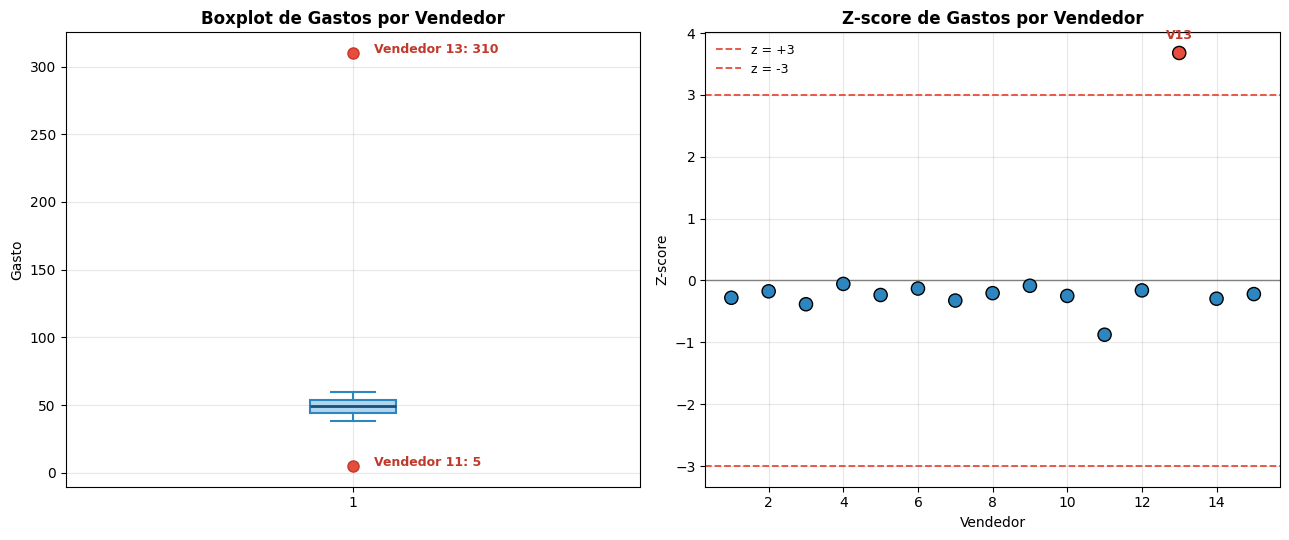

Outliers detectados (z-score, |z| > 3):
    Vendedor  Gasto   z_score
12        13    310  3.677098


In [4]:
# --- Boxplot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

bp = axes[0].boxplot(
    df["Gasto"], vert=True, patch_artist=True,
    boxprops=dict(facecolor="#AED6F1", color="#2E86C1", linewidth=1.5),
    medianprops=dict(color="#1B4F72", linewidth=2),
    whiskerprops=dict(color="#2E86C1", linewidth=1.5),
    capprops=dict(color="#2E86C1", linewidth=1.5),
    flierprops=dict(marker="o", markerfacecolor="#E74C3C", markeredgecolor="#C0392B", markersize=8)
)
axes[0].set_title("Boxplot de Gastos por Vendedor", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Gasto")
axes[0].grid(alpha=0.3)

for _, row in outliers_ric.iterrows():
    axes[0].annotate(f"Vendedor {row['Vendedor']}: {row['Gasto']}",
                      (1, row["Gasto"]), textcoords="offset points",
                      xytext=(15, 0), fontsize=9, color="#C0392B", fontweight="bold")

# --- Z-score ---
media = df["Gasto"].mean()
desv_std = df["Gasto"].std(ddof=0)
df["z_score"] = (df["Gasto"] - media) / desv_std

colores = np.where(df["z_score"].abs() > 3, "#E74C3C", "#2E86C1")

axes[1].scatter(df["Vendedor"], df["z_score"], c=colores, s=90, edgecolor="black", zorder=3)
axes[1].axhline(0, color="gray", linestyle="-", linewidth=1)
axes[1].axhline(3, color="#E74C3C", linestyle="--", linewidth=1.3, label="z = +3")
axes[1].axhline(-3, color="#E74C3C", linestyle="--", linewidth=1.3, label="z = -3")

for _, row in df.iterrows():
    if abs(row["z_score"]) > 3:
        axes[1].annotate(f"V{int(row['Vendedor'])}", (row["Vendedor"], row["z_score"]),
                          textcoords="offset points", xytext=(0, 10),
                          ha="center", fontsize=9, color="#C0392B", fontweight="bold")

axes[1].set_title("Z-score de Gastos por Vendedor", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Vendedor")
axes[1].set_ylabel("Z-score")
axes[1].grid(alpha=0.3)
axes[1].legend(loc="upper left", fontsize=9, frameon=False)

plt.tight_layout()
plt.show()

outliers_z = df[df["z_score"].abs() > 3]
print("Outliers detectados (z-score, |z| > 3):")
print(outliers_z[["Vendedor", "Gasto", "z_score"]])

## 7. Gráfico de control

Se trata cada vendedor como un punto en secuencia (equivalente a una serie temporal de observaciones). La **línea central** es la media del proceso, y los **límites de control** (superior/inferior) se calculan como media ± 3 desviaciones estándar. Cualquier punto fuera de esos límites señala una desviación relevante respecto al comportamiento esperado del proceso.

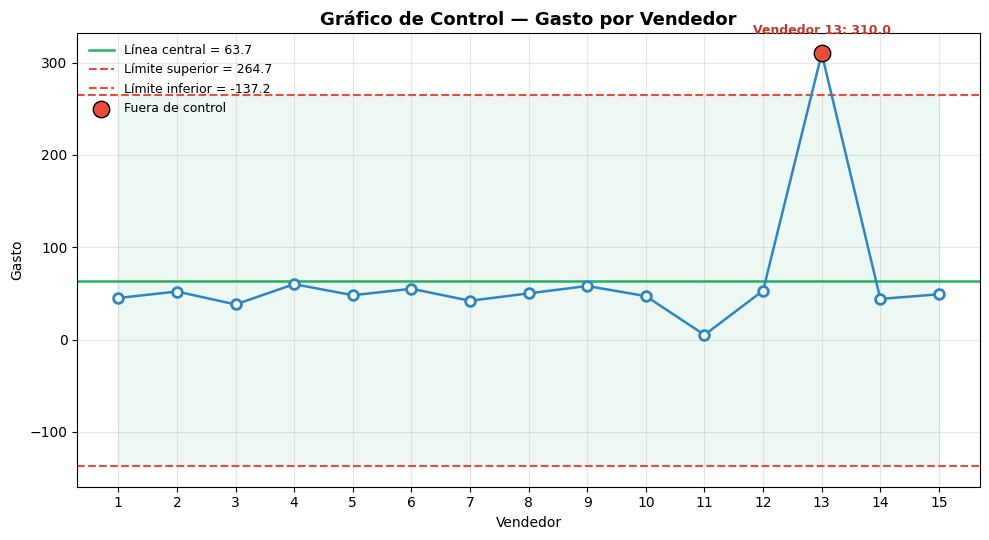

Puntos fuera de los límites de control:
    Vendedor  Gasto
12        13    310


In [5]:
LC = df["Gasto"].mean()
LCS = LC + 3 * desv_std
LCI = LC - 3 * desv_std

fuera_control = df[(df["Gasto"] > LCS) | (df["Gasto"] < LCI)]

plt.figure(figsize=(10, 5.5))

plt.plot(df["Vendedor"], df["Gasto"], marker="o", color="#2E86C1",
         markersize=7, markerfacecolor="white", markeredgewidth=2, linewidth=1.8, zorder=3)

plt.axhline(LC, color="#27AE60", linestyle="-", linewidth=1.8, label=f"Línea central = {LC:.1f}")
plt.axhline(LCS, color="#E74C3C", linestyle="--", linewidth=1.5, label=f"Límite superior = {LCS:.1f}")
plt.axhline(LCI, color="#E74C3C", linestyle="--", linewidth=1.5, label=f"Límite inferior = {LCI:.1f}")
plt.fill_between(df["Vendedor"], LCI, LCS, color="#27AE60", alpha=0.08)

plt.scatter(fuera_control["Vendedor"], fuera_control["Gasto"],
            color="#E74C3C", s=140, zorder=4, edgecolor="black", label="Fuera de control")

for _, row in fuera_control.iterrows():
    plt.annotate(f"Vendedor {int(row['Vendedor'])}: {row['Gasto']}",
                 (row["Vendedor"], row["Gasto"]), textcoords="offset points",
                 xytext=(0, 14), ha="center", fontsize=9, color="#C0392B", fontweight="bold")

plt.title("Gráfico de Control — Gasto por Vendedor", fontsize=13, fontweight="bold")
plt.xlabel("Vendedor")
plt.ylabel("Gasto")
plt.xticks(df["Vendedor"])
plt.grid(alpha=0.3)
plt.legend(loc="upper left", fontsize=9, frameon=False)
plt.tight_layout()
plt.show()

print("Puntos fuera de los límites de control:")
print(fuera_control[["Vendedor", "Gasto"]])

## 8. Gráfico de residuos

Se ajusta una regresión lineal simple de **Gasto vs. Vendedor** para obtener el valor esperado (predicho) en cada punto. El residuo es la diferencia entre el valor real y ese valor esperado (`residuo = real − predicho`). Mientras más se aleje un punto de la línea cero, mayor es su desviación respecto al patrón general de los datos.

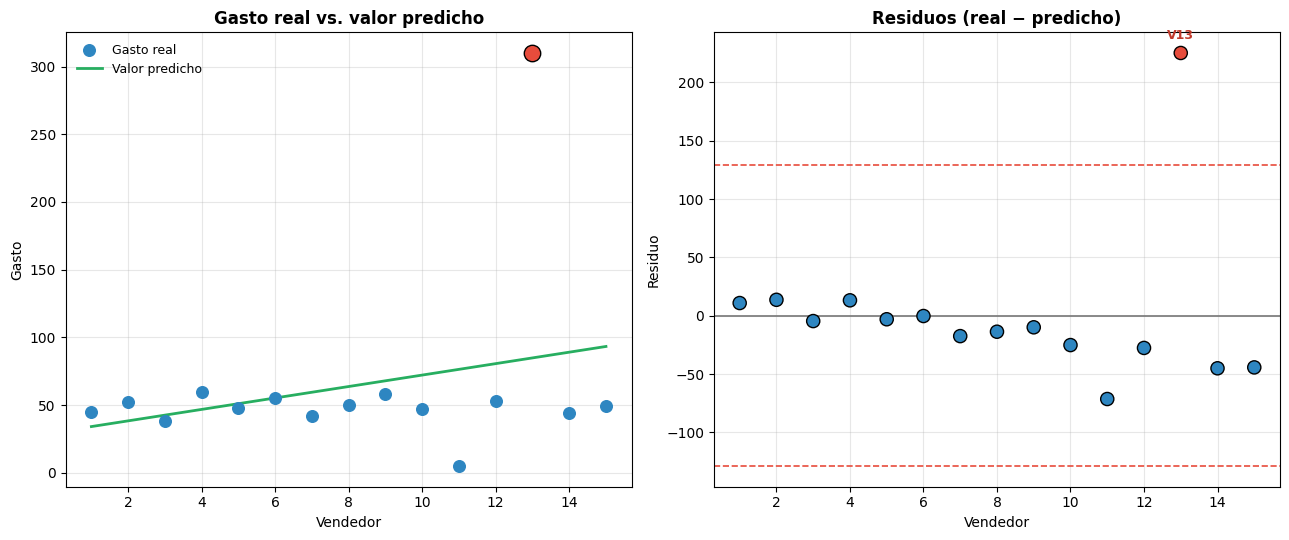

Casos con residuo atípico (|residuo| > 2 desviaciones estándar):
    Vendedor  Gasto  Gasto_predicho  residuo
12        13    310           84.86   225.14


In [6]:
# Ajuste de regresión lineal simple: Gasto ~ Vendedor
pendiente, intercepto = np.polyfit(df["Vendedor"], df["Gasto"], 1)
df["Gasto_predicho"] = pendiente * df["Vendedor"] + intercepto
df["residuo"] = df["Gasto"] - df["Gasto_predicho"]

umbral_residuo = 2 * df["residuo"].std(ddof=0)
residuos_atipicos = df[df["residuo"].abs() > umbral_residuo]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Datos reales vs. línea de regresión
axes[0].scatter(df["Vendedor"], df["Gasto"], color="#2E86C1", s=70, zorder=3, label="Gasto real")
axes[0].plot(df["Vendedor"], df["Gasto_predicho"], color="#27AE60", linewidth=2, label="Valor predicho")
axes[0].scatter(residuos_atipicos["Vendedor"], residuos_atipicos["Gasto"],
                color="#E74C3C", s=140, zorder=4, edgecolor="black")
axes[0].set_title("Gasto real vs. valor predicho", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Vendedor")
axes[0].set_ylabel("Gasto")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=9, frameon=False)

# Residuos
colores_res = np.where(df["residuo"].abs() > umbral_residuo, "#E74C3C", "#2E86C1")
axes[1].scatter(df["Vendedor"], df["residuo"], c=colores_res, s=90, edgecolor="black", zorder=3)
axes[1].axhline(0, color="gray", linewidth=1.3)
axes[1].axhline(umbral_residuo, color="#E74C3C", linestyle="--", linewidth=1.2)
axes[1].axhline(-umbral_residuo, color="#E74C3C", linestyle="--", linewidth=1.2)

for _, row in residuos_atipicos.iterrows():
    axes[1].annotate(f"V{int(row['Vendedor'])}", (row["Vendedor"], row["residuo"]),
                      textcoords="offset points", xytext=(0, 10),
                      ha="center", fontsize=9, color="#C0392B", fontweight="bold")

axes[1].set_title("Residuos (real − predicho)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Vendedor")
axes[1].set_ylabel("Residuo")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Casos con residuo atípico (|residuo| > 2 desviaciones estándar):")
print(residuos_atipicos[["Vendedor", "Gasto", "Gasto_predicho", "residuo"]].round(2))

## 9. Interpretación de resultados

Los cuatro métodos aplicados (RIC/boxplot, z-score, gráfico de control y residuos de regresión) coinciden en señalar al **vendedor 13** (gasto = 310) como el caso claramente atípico: está muy por encima de cualquier límite razonable calculado a partir del resto del grupo.

- **RIC:** 310 supera el límite superior de 68.25.
- **Z-score:** su z-score es muy superior a 3 desviaciones estándar de la media.
- **Gráfico de control:** el punto queda muy por fuera de la banda (media ± 3σ).
- **Residuos:** su residuo frente a la línea de tendencia es, por lejos, el más grande del grupo.

El vendedor 11 (gasto = 5) también aparece por debajo del límite inferior del RIC, aunque su desviación es mucho menos extrema que la del vendedor 13 en los otros tres métodos, ya que la media y la desviación estándar del grupo están fuertemente infladas por el valor 310.

**Recomendación práctica:** antes de usar estos datos para promedios o proyecciones, se recomienda revisar puntualmente el gasto del vendedor 13 (¿viaje excepcional, error de digitación, o gasto real fuera de lo común?), ya que un solo valor extremo como este distorsiona tanto la media como la desviación estándar de todo el conjunto.

## 10. Menú interactivo — seleccionar una tabla o gráfica por número

Ejecutá esta celda **después** de correr todas las celdas anteriores del notebook. Permite volver a mostrar, bajo demanda, cualquier tabla o gráfica ya generada, escribiendo el número correspondiente.

In [ ]:
# ==========================================================================
# MENÚ INTERACTIVO — seleccionar una tabla o gráfica por número
# ==========================================================================
# IMPORTANTE: ejecutar esta celda DESPUÉS de correr todas las celdas
# anteriores del notebook. El menú reutiliza las variables ya calculadas
# arriba (df, Q1, Q3, RIC, límites, LC, LCS, LCI, pendiente, intercepto,
# umbral_residuo, etc.) para volver a mostrar, bajo demanda, cualquier
# tabla o gráfica ya generada.

from IPython.display import display

def _explicar(titulo, texto):
    """Imprime un encabezado y una explicación detallada antes de mostrar
    la tabla o gráfica correspondiente a la opción elegida."""
    print("\n" + "-" * 65)
    print(f"📌 {titulo}")
    print("-" * 65)
    print(texto)
    print()

def menu_gastos():
    while True:
        print("\n" + "=" * 65)
        print(" MENÚ — Detección de Outliers: Gastos por Vendedor")
        print("=" * 65)
        print(""" 1. Tabla de datos (Vendedor, Gasto)
 2. Cuartiles (Q1, Q3) y Rango Intercuartílico (RIC)
 3. Outliers detectados por el método RIC
 4. Boxplot y Z-score (gráfico combinado)
 5. Gráfico de control (media ± 3 desviaciones estándar)
 6. Gráfico de residuos (regresión Gasto ~ Vendedor)
 7. Interpretación final de resultados
 0. Salir del menú""")
        eleccion = input("\nElegí un número de opción: ").strip()

        if eleccion == "1":
            # Tabla base del ejercicio: el gasto de viáticos registrado para cada
            # uno de los 15 vendedores. Es el punto de partida de los cuatro
            # métodos de detección de outliers que se aplican más adelante (RIC,
            # z-score, gráfico de control y residuos de regresión).
            _explicar(
                "Tabla de datos (Vendedor, Gasto)",
                "Gasto de viáticos registrado para cada uno de los 15 vendedores.\n"
                "Es el punto de partida de los cuatro métodos de detección de\n"
                "outliers aplicados en este notebook."
            )
            display(df[["Vendedor", "Gasto"]])

        elif eleccion == "2":
            # Q1 y Q3 son el 25% y el 75% de los datos ordenados; RIC = Q3 - Q1 mide
            # la dispersión del "cuerpo central" de los datos, ignorando los
            # extremos. Los límites inferior y superior (Q1 - 1.5·RIC y
            # Q3 + 1.5·RIC) son la regla clásica de Tukey para marcar un valor
            # como atípico.
            _explicar(
                "Cuartiles y Rango Intercuartílico (RIC)",
                "Q1 y Q3 son el percentil 25 y 75 de los gastos ordenados; RIC =\n"
                "Q3 − Q1 mide la dispersión del cuerpo central de los datos. Los\n"
                "límites (Q1 − 1.5·RIC y Q3 + 1.5·RIC) son la regla clásica de\n"
                "Tukey para marcar un valor como atípico."
            )
            print(f"Q1 = {Q1}")
            print(f"Q3 = {Q3}")
            print(f"RIC = {RIC}")
            print(f"Límite inferior = {limite_inferior}")
            print(f"Límite superior = {limite_superior}")

        elif eleccion == "3":
            # Filtra la tabla de gastos dejando solo los vendedores cuyo gasto cae
            # fuera del rango [límite inferior, límite superior] calculado en la
            # opción 2. Es la aplicación directa de la regla de Tukey sobre estos
            # 15 datos.
            _explicar(
                "Outliers detectados por el método RIC",
                "Filtra los vendedores cuyo gasto cae fuera del rango [límite\n"
                "inferior, límite superior] calculado con el RIC (opción 2). Es la\n"
                "aplicación directa de la regla de Tukey sobre los 15 datos."
            )
            outliers_ric_ = df[(df["Gasto"] < limite_inferior) | (df["Gasto"] > limite_superior)]
            print("Outliers detectados (RIC):")
            print(outliers_ric_)

        elif eleccion == "4":
            # Panel izquierdo: boxplot clásico, donde la "caja" son Q1-Q3 y los
            # puntos fuera de los bigotes son outliers según el RIC. Panel derecho:
            # z-score de cada vendedor, es decir, cuántas desviaciones estándar se
            # aleja su gasto de la media del grupo; por convención, |z| > 3 se
            # considera atípico. Ambos métodos son complementarios: el boxplot es
            # más sensible con datos pequeños, el z-score depende fuertemente de la
            # media y desviación estándar (que un valor muy extremo puede inflar).
            _explicar(
                "Boxplot y Z-score",
                "Izquierda: boxplot clásico (la caja son Q1-Q3; los puntos fuera de\n"
                "los bigotes son outliers por RIC). Derecha: z-score de cada\n"
                "vendedor (desviaciones estándar respecto a la media); por\n"
                "convención |z| > 3 se considera atípico. El boxplot es más\n"
                "sensible con muestras chicas; el z-score depende de la media y\n"
                "desviación estándar, que un valor extremo puede inflar."
            )
            outliers_ric_ = df[(df["Gasto"] < limite_inferior) | (df["Gasto"] > limite_superior)]
            fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
            axes[0].boxplot(
                df["Gasto"], vert=True, patch_artist=True,
                boxprops=dict(facecolor="#AED6F1", color="#2E86C1", linewidth=1.5),
                medianprops=dict(color="#1B4F72", linewidth=2),
                whiskerprops=dict(color="#2E86C1", linewidth=1.5),
                capprops=dict(color="#2E86C1", linewidth=1.5),
                flierprops=dict(marker="o", markerfacecolor="#E74C3C", markeredgecolor="#C0392B", markersize=8)
            )
            axes[0].set_title("Boxplot de Gastos por Vendedor", fontsize=12, fontweight="bold")
            axes[0].set_ylabel("Gasto")
            axes[0].grid(alpha=0.3)
            for _, row in outliers_ric_.iterrows():
                axes[0].annotate(f"Vendedor {row['Vendedor']}: {row['Gasto']}",
                                  (1, row["Gasto"]), textcoords="offset points",
                                  xytext=(15, 0), fontsize=9, color="#C0392B", fontweight="bold")
            colores_z = np.where(df["z_score"].abs() > 3, "#E74C3C", "#2E86C1")
            axes[1].scatter(df["Vendedor"], df["z_score"], c=colores_z, s=90, edgecolor="black", zorder=3)
            axes[1].axhline(0, color="gray", linestyle="-", linewidth=1)
            axes[1].axhline(3, color="#E74C3C", linestyle="--", linewidth=1.3, label="z = +3")
            axes[1].axhline(-3, color="#E74C3C", linestyle="--", linewidth=1.3, label="z = -3")
            for _, row in df.iterrows():
                if abs(row["z_score"]) > 3:
                    axes[1].annotate(f"V{int(row['Vendedor'])}", (row["Vendedor"], row["z_score"]),
                                      textcoords="offset points", xytext=(0, 10),
                                      ha="center", fontsize=9, color="#C0392B", fontweight="bold")
            axes[1].set_title("Z-score de Gastos por Vendedor", fontsize=12, fontweight="bold")
            axes[1].set_xlabel("Vendedor")
            axes[1].set_ylabel("Z-score")
            axes[1].grid(alpha=0.3)
            axes[1].legend(loc="upper left", fontsize=9, frameon=False)
            plt.tight_layout()
            plt.show()
            outliers_z_ = df[df["z_score"].abs() > 3]
            print("Outliers detectados (z-score, |z| > 3):")
            print(outliers_z_[["Vendedor", "Gasto", "z_score"]])

        elif eleccion == "5":
            # Trata a cada vendedor como un punto en secuencia, como si fuera una
            # serie temporal de observaciones. La línea central (verde) es la media
            # del grupo; los límites de control (rojo punteado) son media ± 3
            # desviaciones estándar. Cualquier punto fuera de esa banda se marca
            # como "fuera de control", es decir, una desviación relevante respecto
            # al comportamiento esperado del proceso.
            _explicar(
                "Gráfico de control",
                "Trata a cada vendedor como un punto en secuencia. La línea central\n"
                "(verde) es la media del grupo; los límites de control (rojo\n"
                "punteado) son media ± 3 desviaciones estándar. Un punto fuera de\n"
                "esa banda se marca como 'fuera de control'."
            )
            fuera_control_ = df[(df["Gasto"] > LCS) | (df["Gasto"] < LCI)]
            plt.figure(figsize=(10, 5.5))
            plt.plot(df["Vendedor"], df["Gasto"], marker="o", color="#2E86C1",
                     markersize=7, markerfacecolor="white", markeredgewidth=2, linewidth=1.8, zorder=3)
            plt.axhline(LC, color="#27AE60", linestyle="-", linewidth=1.8, label=f"Línea central = {LC:.1f}")
            plt.axhline(LCS, color="#E74C3C", linestyle="--", linewidth=1.5, label=f"Límite superior = {LCS:.1f}")
            plt.axhline(LCI, color="#E74C3C", linestyle="--", linewidth=1.5, label=f"Límite inferior = {LCI:.1f}")
            plt.fill_between(df["Vendedor"], LCI, LCS, color="#27AE60", alpha=0.08)
            plt.scatter(fuera_control_["Vendedor"], fuera_control_["Gasto"],
                        color="#E74C3C", s=140, zorder=4, edgecolor="black", label="Fuera de control")
            for _, row in fuera_control_.iterrows():
                plt.annotate(f"Vendedor {int(row['Vendedor'])}: {row['Gasto']}",
                             (row["Vendedor"], row["Gasto"]), textcoords="offset points",
                             xytext=(0, 14), ha="center", fontsize=9, color="#C0392B", fontweight="bold")
            plt.title("Gráfico de Control — Gasto por Vendedor", fontsize=13, fontweight="bold")
            plt.xlabel("Vendedor")
            plt.ylabel("Gasto")
            plt.xticks(df["Vendedor"])
            plt.grid(alpha=0.3)
            plt.legend(loc="upper left", fontsize=9, frameon=False)
            plt.tight_layout()
            plt.show()
            print("Puntos fuera de los límites de control:")
            print(fuera_control_[["Vendedor", "Gasto"]])

        elif eleccion == "6":
            # Ajusta una regresión lineal simple de Gasto contra Vendedor para
            # obtener el valor "esperado" (predicho) en cada punto. El residuo es
            # la diferencia entre lo real y lo predicho; mientras más se aleje un
            # punto de la línea cero (panel derecho), mayor es su desviación
            # respecto al patrón general de los datos. El panel izquierdo muestra
            # los datos reales junto a la línea de regresión que los predice.
            _explicar(
                "Gráfico de residuos",
                "Ajusta una regresión lineal Gasto ~ Vendedor para obtener el valor\n"
                "esperado en cada punto. El residuo es real − predicho; mientras más\n"
                "se aleje un punto de la línea cero (panel derecho), mayor es su\n"
                "desviación respecto al patrón general."
            )
            umbral_residuo_ = 2 * df["residuo"].std(ddof=0)
            residuos_atipicos_ = df[df["residuo"].abs() > umbral_residuo_]
            fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
            axes[0].scatter(df["Vendedor"], df["Gasto"], color="#2E86C1", s=70, zorder=3, label="Gasto real")
            axes[0].plot(df["Vendedor"], df["Gasto_predicho"], color="#27AE60", linewidth=2, label="Valor predicho")
            axes[0].scatter(residuos_atipicos_["Vendedor"], residuos_atipicos_["Gasto"],
                            color="#E74C3C", s=140, zorder=4, edgecolor="black")
            axes[0].set_title("Gasto real vs. valor predicho", fontsize=12, fontweight="bold")
            axes[0].set_xlabel("Vendedor")
            axes[0].set_ylabel("Gasto")
            axes[0].grid(alpha=0.3)
            axes[0].legend(fontsize=9, frameon=False)
            colores_res_ = np.where(df["residuo"].abs() > umbral_residuo_, "#E74C3C", "#2E86C1")
            axes[1].scatter(df["Vendedor"], df["residuo"], c=colores_res_, s=90, edgecolor="black", zorder=3)
            axes[1].axhline(0, color="gray", linewidth=1.3)
            axes[1].axhline(umbral_residuo_, color="#E74C3C", linestyle="--", linewidth=1.2)
            axes[1].axhline(-umbral_residuo_, color="#E74C3C", linestyle="--", linewidth=1.2)
            for _, row in residuos_atipicos_.iterrows():
                axes[1].annotate(f"V{int(row['Vendedor'])}", (row["Vendedor"], row["residuo"]),
                                  textcoords="offset points", xytext=(0, 10),
                                  ha="center", fontsize=9, color="#C0392B", fontweight="bold")
            axes[1].set_title("Residuos (real − predicho)", fontsize=12, fontweight="bold")
            axes[1].set_xlabel("Vendedor")
            axes[1].set_ylabel("Residuo")
            axes[1].grid(alpha=0.3)
            plt.tight_layout()
            plt.show()
            print("Casos con residuo atípico (|residuo| > 2 desviaciones estándar):")
            print(residuos_atipicos_[["Vendedor", "Gasto", "Gasto_predicho", "residuo"]].round(2))

        elif eleccion == "7":
            # Recapitula lo que muestran, en conjunto, los cuatro métodos
            # aplicados (RIC, z-score, gráfico de control y residuos): todos
            # señalan al mismo vendedor como el caso claramente atípico, y explica
            # por qué el vendedor 11 aparece marcado solo por RIC pero no por los
            # otros métodos (su media y desviación estándar del grupo están
            # infladas por el valor extremo).
            _explicar(
                "Interpretación final de resultados",
                "Recapitula lo que muestran en conjunto los cuatro métodos (RIC,\n"
                "z-score, gráfico de control y residuos) y explica por qué el\n"
                "vendedor 11 se marca solo por RIC y no por los otros métodos."
            )
            print("Los cuatro métodos aplicados (RIC/boxplot, z-score, gráfico de control y residuos")
            print("de regresión) coinciden en señalar al vendedor 13 (gasto = 310) como el caso")
            print("claramente atípico: está muy por encima de cualquier límite razonable calculado")
            print("a partir del resto del grupo.")
            print()
            print("- RIC: 310 supera el límite superior de 68.25.")
            print("- Z-score: su z-score es muy superior a 3 desviaciones estándar de la media.")
            print("- Gráfico de control: el punto queda muy por fuera de la banda (media ± 3σ).")
            print("- Residuos: su residuo frente a la línea de tendencia es, por lejos, el más grande.")
            print()
            print("El vendedor 11 (gasto = 5) también aparece por debajo del límite inferior del RIC,")
            print("aunque su desviación es mucho menos extrema en los otros tres métodos, ya que la")
            print("media y la desviación estándar del grupo están fuertemente infladas por el 310.")
            print()
            print("Recomendación práctica: antes de usar estos datos para promedios o proyecciones,")
            print("conviene revisar puntualmente el gasto del vendedor 13, ya que un solo valor")
            print("extremo distorsiona tanto la media como la desviación estándar de todo el conjunto.")

        elif eleccion == "0":
            print("Saliendo del menú.")
            break

        else:
            print("⚠️  Opción no válida. Elegí un número entre 0 y 7.")

menu_gastos()
